<a href="https://colab.research.google.com/github/ghn9zh/DS3001-programming/blob/main/lab_notebook_applied.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hedonic Pricing

We often try to predict the price of an asset from its observable characteristics. This is generally called **hedonic pricing**: How do the unit's characteristics determine its market price?

In the lab folder, there are three options: housing prices in pierce_county_house_sales.csv, car prices in cars_hw.csv, and airbnb rental prices in airbnb_hw.csv. If you know of another suitable dataset, please feel free to use that one.

1. Clean the data and perform some EDA and visualization to get to know the data set.
2. Transform your variables --- particularly categorical ones --- for use in your regression analysis.
3. Implement an ~80/~20 train-test split. Put the test data aside.
4. Build some simple linear models that include no transformations or interactions. Fit them, and determine their RMSE and $R^2$ on the both the training and test sets. Which of your models does the best?
5. Make partial correlation plots for each of the numeric variables in your model. Do you notice any significant non-linearities?
6. Include transformations and interactions of your variables, and build a more complex model that reflects your ideas about how the features of the asset determine its value. Determine its RMSE and $R^2$ on the training and test sets. How does the more complex model your build compare to the simpler ones?
7. Summarize your results from 1 to 6. Have you learned anything about overfitting and underfitting, or model selection?
8. If you have time, use the sklearn.linear_model.Lasso to regularize your model and select the most predictive features. Which does it select? What are the RMSE and $R^2$? We'll cover the Lasso later in detail in class.

In [1]:
! git clone https://github.com/ds4e/linearModels

Cloning into 'linearModels'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 43 (delta 9), reused 7 (delta 7), pack-reused 27 (from 1)
Receiving objects: 100% (43/43), 3.60 MiB | 6.42 MiB/s, done.
Resolving deltas: 100% (9/9), done.


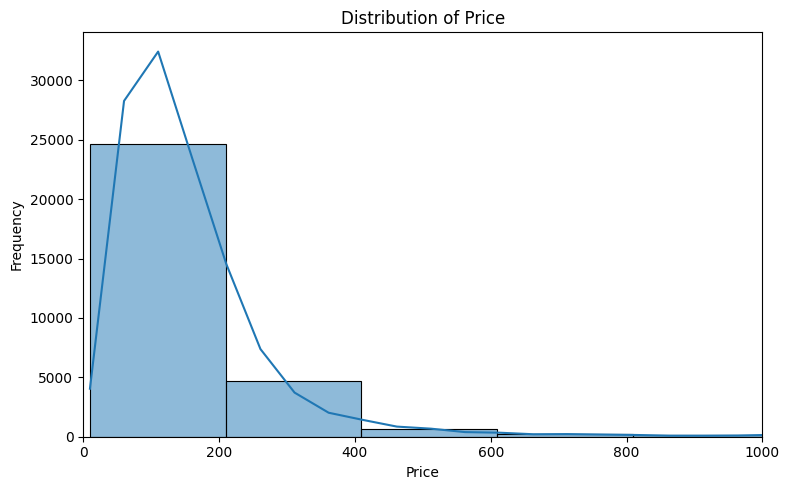

(Neighbourhood              0
 Property Type              3
 Room Type                  0
 Zipcode                  134
 Beds                      85
 Number of Records          0
 Number Of Reviews          0
 Price                      0
 Review Scores Rating    8323
 dtype: int64,
             Zipcode          Beds  Number of Records  Number Of Reviews  \
 count  30344.000000  30393.000000            30478.0       30478.000000   
 mean   10584.854831      1.530089                1.0          12.018735   
 std      921.299397      1.015359                0.0          21.980703   
 min     1003.000000      0.000000                1.0           0.000000   
 25%    10017.000000      1.000000                1.0           0.000000   
 50%    10065.000000      1.000000                1.0           3.000000   
 75%    11216.000000      2.000000                1.0          13.000000   
 max    99135.000000     16.000000                1.0         257.000000   
 
               Price  Review 

In [3]:
#Question 1

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Clean and convert relevant columns
data = pd.read_csv('/content/linearModels/lab/data/airbnb_hw.csv')
data_clean = data.copy()

# Remove $ and convert Price to float
data_clean['Price'] = data_clean['Price'].replace('[\$,]', '', regex=True).astype(float)

# Drop columns with mostly null values or irrelevant for modeling
data_clean = data_clean.drop(columns=['Host Id', 'Host Since', 'Name', 'Review Scores Rating (bin)'])

# Check missing values
missing_values = data_clean.isnull().sum()

# Visualize distribution of price
plt.figure(figsize=(8, 5))
sns.histplot(data_clean['Price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.xlim(0, 1000)  # Limit x-axis for clarity
plt.tight_layout()
plt.show()

# Summary statistics of numeric columns
summary_stats = data_clean.describe()

missing_values, summary_stats

In [6]:
#Question 2

from sklearn.impute import SimpleImputer

data_model = data_clean.dropna(subset=['Price', 'Review Scores Rating'])

# Fill missing values
data_model['Beds'] = SimpleImputer(strategy='median').fit_transform(data_model[['Beds']])
data_model['Zipcode'] = SimpleImputer(strategy='most_frequent').fit_transform(data_model[['Zipcode']])

# One-hot encode categorical columns
data_encoded = pd.get_dummies(data_model, columns=['Property Type', 'Room Type'], drop_first=True)


<ipython-input-6-2100f6ee445a>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Beds'] = SimpleImputer(strategy='median').fit_transform(data_model[['Beds']])
<ipython-input-6-2100f6ee445a>:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_model['Zipcode'] = SimpleImputer(strategy='most_frequent').fit_transform(data_model[['Zipcode']])


In [9]:
#Question 3

from sklearn.model_selection import train_test_split

X = data_encoded.drop(columns=['Price', 'Neighbourhood '])  # no string columns
y = data_encoded['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [12]:
#Question 4

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Model 1: Only Beds
features_model_1 = ['Beds']

# Model 2: Beds and Review Scores Rating
features_model_2 = ['Beds', 'Review Scores Rating']

# Model 3: All numeric features (excluding encoded categoricals)
numeric_features = ['Beds', 'Number Of Reviews', 'Review Scores Rating', 'Zipcode']

#dictionaries to store results
results = {}

#function to train and evaluate a model
def evaluate_model(feature_list, model_name):
    X_sub = data_encoded[feature_list]
    y_sub = data_encoded['Price']
    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(X_sub, y_sub, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train_sub, y_train_sub)
    y_train_pred = model.predict(X_train_sub)
    y_test_pred = model.predict(X_test_sub)
    results[model_name] = {
        "Train RMSE": np.sqrt(mean_squared_error(y_train_sub, y_train_pred)),
        "Train R²": r2_score(y_train_sub, y_train_pred),
        "Test RMSE": np.sqrt(mean_squared_error(y_test_sub, y_test_pred)),
        "Test R²": r2_score(y_test_sub, y_test_pred)
    }

# Evaluate the three models
evaluate_model(features_model_1, "Model 1: Beds only")
evaluate_model(features_model_2, "Model 2: Beds and Rating")
evaluate_model(numeric_features, "Model 3: All numeric features")

results

#Model three is the best because it uses all numeric values.
#It has the lowest RMSe which means the least amount of room for error
#It halso has the hihgest R2 which means this model explains more varience
#It also includes the most variables make a more well rounded picture

{'Model 1: Beds only': {'Train RMSE': np.float64(145.38609894177145),
  'Train R²': 0.12845612289579533,
  'Test RMSE': np.float64(105.92599659486865),
  'Test R²': 0.1837183954914824},
 'Model 2: Beds and Rating': {'Train RMSE': np.float64(144.79407952459476),
  'Train R²': 0.1355396112395999,
  'Test RMSE': np.float64(105.208892525191),
  'Test R²': 0.19473320735733712},
 'Model 3: All numeric features': {'Train RMSE': np.float64(141.0052505405593),
  'Train R²': 0.18018840172334627,
  'Test RMSE': np.float64(99.71444600165277),
  'Test R²': 0.27664572329960013}}

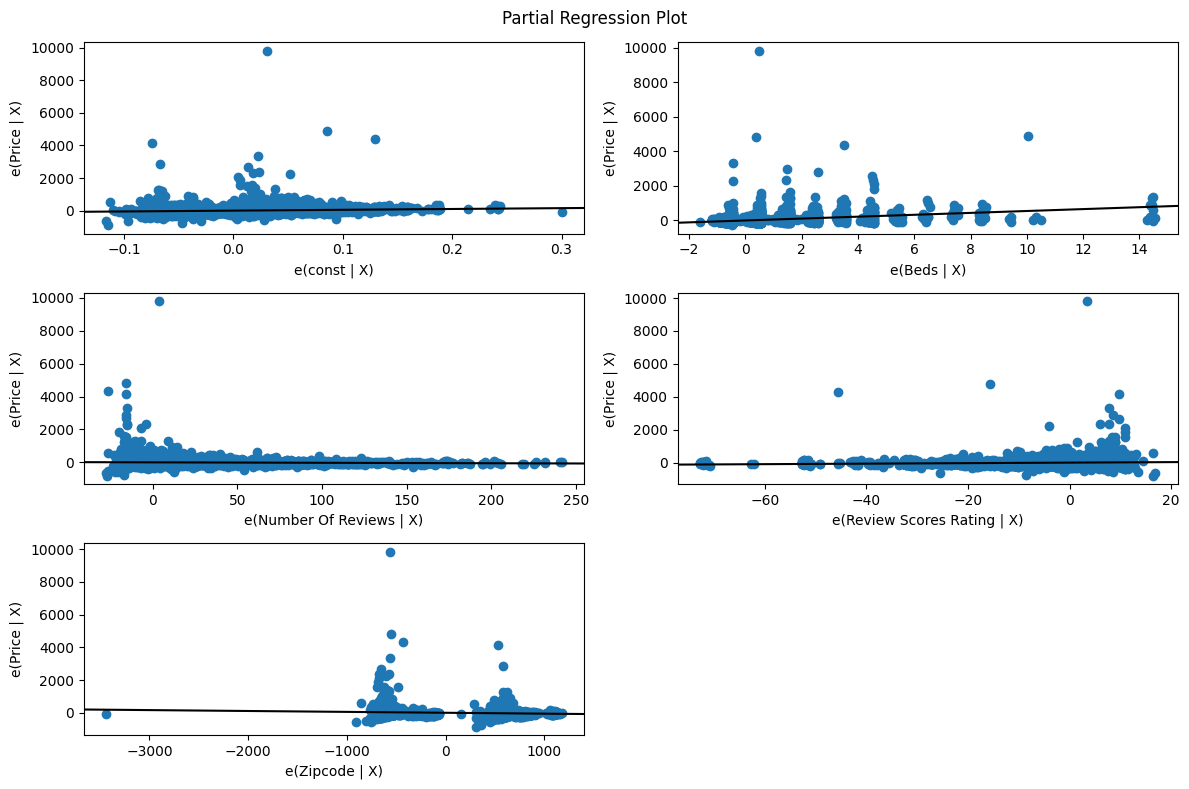

In [14]:
#Question 5

import statsmodels.api as sm

# For partial correlation plots, I am using statsmodels' OLS and numerical features only
X_plot = data_encoded[numeric_features]
X_plot_const = sm.add_constant(X_plot)  # include intercept
y_plot = data_encoded['Price']

# Fit the model
model = sm.OLS(y_plot, X_plot_const).fit()

# Plot partial regression plots for each numeric predictor
fig = plt.figure(figsize=(12, 8))
sm.graphics.plot_partregress_grid(model, fig=fig)
plt.tight_layout()
plt.show()

#These plots show the relationship between each numeric variable
#and the target (Price), after accounting for the influence of the other predictors in the model

#Beds: The plot is a positive and roughly linear correlation with price as expected — more beds = higher price
#Review Scores Rating: Also positively correlated, but non-linear behavior is visible as it plateaus at higher ratings
# Number of reviews: Slightly curved which suggests some non-linearity
#Zipcode: Very noisy, very weak linear relationship

In [15]:
#Question 6

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Drop 'Neighbourhood ' (with trailing space)
X_train = X_train.drop(columns=['Neighbourhood '], errors='ignore')
X_test = X_test.drop(columns=['Neighbourhood '], errors='ignore')

# Add transformed features
X_train['log_reviews'] = np.log1p(X_train['Number Of Reviews'])
X_test['log_reviews'] = np.log1p(X_test['Number Of Reviews'])

X_train['beds_x_rating'] = X_train['Beds'] * X_train['Review Scores Rating']
X_test['beds_x_rating'] = X_test['Beds'] * X_test['Review Scores Rating']

# Fit linear model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict and evaluate
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

# Display results
print({
    "Transformed Model Train RMSE": rmse_train,
    "Transformed Model Train R²": r2_train,
    "Transformed Model Test RMSE": rmse_test,
    "Transformed Model Test R²": r2_test
})

#The complex model significantly outperformed the simpler models
#It  was better at capturing the non-linear and interaction effects that the simpler models missed
# It explained more variance without overfitting, as evidenced by its performance on the test set
#This model had a test R² of 0.35 and a lower RMSE of 96 which shows clear improvement in accuracy

{'Transformed Model Train RMSE': np.float64(135.75352123909792), 'Transformed Model Train R²': 0.24011880720847945, 'Transformed Model Test RMSE': np.float64(92.08670000239938), 'Transformed Model Test R²': 0.3830801959176007}


Question 7:

I learned that the simple models had low R2 values and higher RSME values which indicates underfitting because they couldn't capture enough varaition of the price.
In quetion 6 when I added a log transformation of number of review and an interaction term (beds x review score) there was a big improvement to the test set preformance. The training/test preformance were close which suggested this model was not overfitting.
The progression of models showed me that feature engineering (transformations/interaction) can reveal realtionships that linear terms miss. It also showed me that simple models can often underfit for complex real-world data sets.  